In [41]:
import requests
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv('data/kobis.csv')

In [28]:
df.shape

(3650, 7)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   날짜      3650 non-null   int64
 1   순위      3650 non-null   int64
 2   영화명     3650 non-null   str  
 3   개봉일     3650 non-null   str  
 4   일일관객수   3650 non-null   int64
 5   누적관객수   3650 non-null   int64
 6   일일매출액   3650 non-null   int64
dtypes: int64(5), str(2)
memory usage: 199.7 KB


In [30]:
df.head()

,날짜,순위,영화명,개봉일,일일관객수,누적관객수,일일매출액
0,20250101,1,하얼빈,2024-12-24,340484,3095720,3290065760
1,20250101,2,보고타: 마지막 기회의 땅,2024-12-31,93154,194095,880276910
2,20250101,3,소방관,2024-12-04,80830,3398126,769063260
3,20250101,4,수퍼 소닉3,2025-01-01,75916,97373,705207940
4,20250101,5,뽀로로 극장판 바닷속 대모험,2025-01-01,58882,92837,512345060


In [ ]:
df['영화명'].value_counts()

In [ ]:
df['순위'].value_counts()

## 월별 박스오피스 1등 리스트업

In [31]:
df.dtypes

날짜       int64
순위       int64
영화명        str
개봉일        str
일일관객수    int64
누적관객수    int64
일일매출액    int64
dtype: object

In [18]:
# 수집한 파일 kobis.csv 파일로 저장
df.to_csv('data/kobis.csv', encoding='utf-8', index=False)

In [32]:
df['날짜'] = pd.to_datetime(df['날짜'], format='%Y%m%d')
df['연'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month
df['일'] = df['날짜'].dt.day

week_dict = {
    0 : '월',
    1 : '화',
    2 : '수',
    3 : '목',
    4 : '금',
    5 : '토',
    6 : '일'
}
df['요일'] = df['날짜'].dt.weekday.map(week_dict)

df.head()

,날짜,순위,영화명,개봉일,일일관객수,누적관객수,일일매출액,연,월,일,요일
0,2025-01-01,1,하얼빈,2024-12-24,340484,3095720,3290065760,2025,1,1,수
1,2025-01-01,2,보고타: 마지막 기회의 땅,2024-12-31,93154,194095,880276910,2025,1,1,수
2,2025-01-01,3,소방관,2024-12-04,80830,3398126,769063260,2025,1,1,수
3,2025-01-01,4,수퍼 소닉3,2025-01-01,75916,97373,705207940,2025,1,1,수
4,2025-01-01,5,뽀로로 극장판 바닷속 대모험,2025-01-01,58882,92837,512345060,2025,1,1,수


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      3650 non-null   datetime64[ns]
 1   순위      3650 non-null   int64         
 2   영화명     3650 non-null   str           
 3   개봉일     3650 non-null   str           
 4   일일관객수   3650 non-null   int64         
 5   누적관객수   3650 non-null   int64         
 6   일일매출액   3650 non-null   int64         
 7   연       3650 non-null   int32         
 8   월       3650 non-null   int32         
 9   일       3650 non-null   int32         
 10  요일      3650 non-null   str           
dtypes: datetime64[ns](1), int32(3), int64(4), str(3)
memory usage: 271.0 KB


In [16]:
df['순위'].value_counts()

순위
1     365
2     365
3     365
4     365
5     365
6     365
7     365
8     365
9     365
10    365
Name: count, dtype: int64

In [43]:
df_rank1 = df[df['순위'] == '1']
df_rank1

# 2025년도 기준 Top of Top 10
df['일일관객수'] = df['일일관객수'].astype(int)
df['일일관객수'].dtypes
df_rank1_top10 = df.groupby('영화명')['일일관객수'].sum().sort_values(ascending=False).head(10)
df_rank1_top10

영화명
주토피아 2              7703922
극장판 귀멸의 칼날: 무한성편    5650903
좀비딸                 5605086
F1 더 무비             5176850
아바타: 불과 재           4568158
극장판 체인소 맨: 레제편      3406687
미션 임파서블: 파이널 레코닝    3380126
야당                  3370527
미키 17               2996149
어쩔수가없다              2925337
Name: 일일관객수, dtype: int64

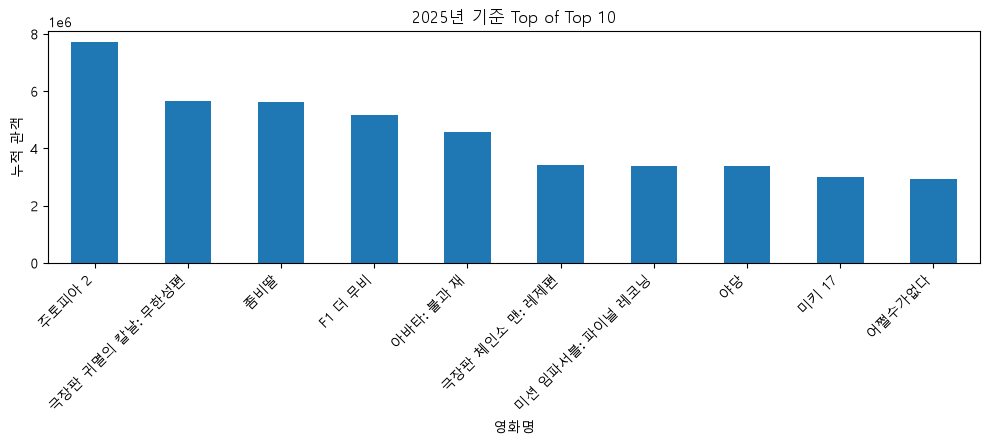

In [49]:
import matplotlib.pyplot as plt

df_rank1_top10.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.title('2025년 기준 Top of Top 10')
plt.ylabel('누적 관객')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')

plt.show()

## 월별 총 매출액 기준 Top10
- 그래프 생성시 월별로 정렬(1 ~ 12)

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      3650 non-null   datetime64[us]
 1   순위      3650 non-null   str           
 2   영화명     3650 non-null   str           
 3   개봉일     3650 non-null   str           
 4   일일관객수   3650 non-null   int64         
 5   누적관객수   3650 non-null   str           
 6   일일매출액   3650 non-null   int64         
 7   연       3650 non-null   int32         
 8   월       3650 non-null   int32         
 9   일       3650 non-null   int32         
 10  요일      3650 non-null   str           
dtypes: datetime64[us](1), int32(3), int64(2), str(5)
memory usage: 271.0 KB


In [61]:
df['일일매출액'] = df['일일매출액'].astype(int)
df_rank1_month_top10 = df.groupby('월')['일일매출액'].sum()
df_rank1_month_top10

월
1      76426460660
2      47082683466
3      55772809470
4      46966204130
5      77570405180
6      69262625020
7     108647423776
8     126989955840
9      70064275110
10     89208664310
11     65397825630
12    134856286132
Name: 일일매출액, dtype: int64

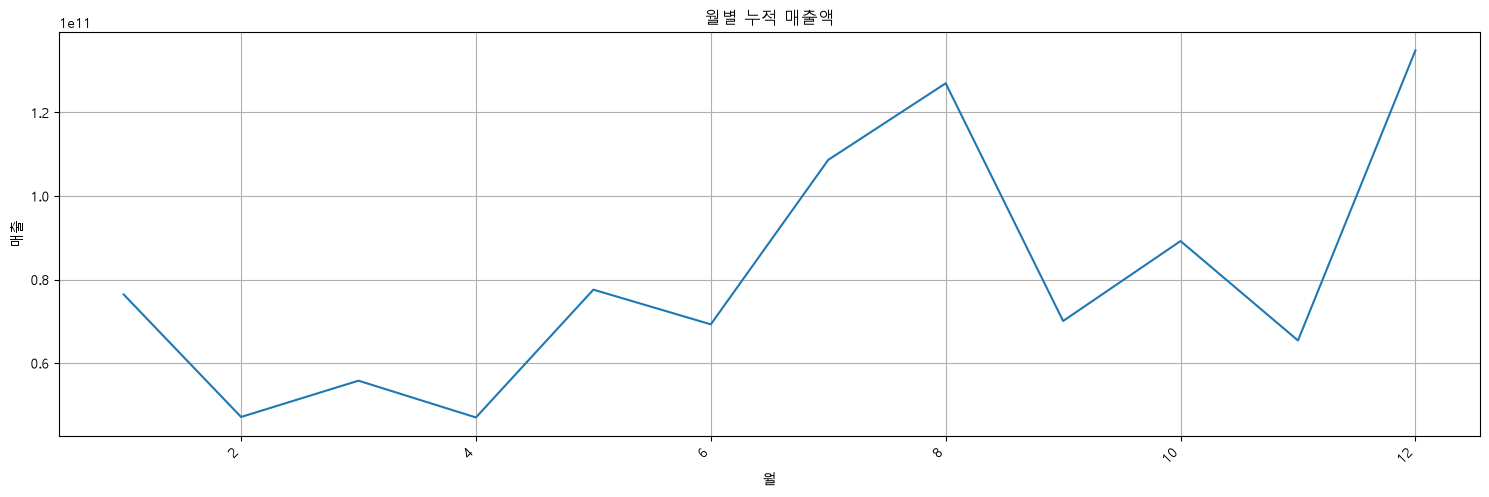

In [67]:
df_rank1_month_top10.plot(
    kind='line',
    figsize=(15, 5)
)
plt.title('월별 누적 매출액')
plt.ylabel('매출')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')

plt.grid()

plt.show()

## 요일별 관객수 추이

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      3650 non-null   datetime64[us]
 1   순위      3650 non-null   int64         
 2   영화명     3650 non-null   str           
 3   개봉일     3650 non-null   str           
 4   일일관객수   3650 non-null   int64         
 5   누적관객수   3650 non-null   int64         
 6   일일매출액   3650 non-null   int64         
 7   연       3650 non-null   int32         
 8   월       3650 non-null   int32         
 9   일       3650 non-null   int32         
 10  요일      3650 non-null   str           
dtypes: datetime64[us](1), int32(3), int64(4), str(3)
memory usage: 271.0 KB


In [33]:
df['요일'].value_counts()

요일
수    530
목    520
금    520
토    520
일    520
월    520
화    520
Name: count, dtype: int64

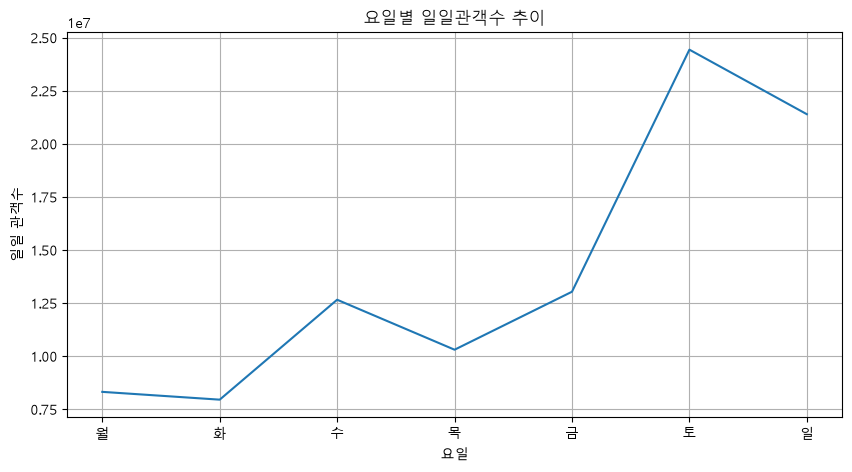

In [43]:
weekday = ['월','화','수','목','금','토','일']
df_weekday = df.groupby('요일')['일일관객수'].sum().reindex(weekday)
df_weekday

df_weekday.plot(
    kind='line',
    figsize= (10,5)
)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.title('요일별 일일관객수 추이')
plt.ylabel('일일 관객수')
plt.grid()
plt.show()